# Week 15 Convolutional Neural Networks
Convolutional Neural Networks use **convolutions** to capture spatial relationships within high-dimensional and complex data. The most common example is image classification and processing, where images tend to be stored in 3 layers of 2-dimensional arrays with each layer a 2x2 image with pixel values representing the saturation of red, blue and green. As with the previous tutorial, we aim to simplify some very complex topics into the short time we have available but we recommend you take the time to view some more in-depth resources if you have the time.
[CNN Explainer](https://poloclub.github.io/cnn-explainer/) is an online resource with several attached videos explaining the below topic in finer detail.
Similarly [Medium](https://pavisj.medium.com/convolutions-and-backpropagations-46026a8f5d2c) have a useful article going through the training process using backpropagation.

## 1 How do Convolutional Neural Networks work?

### 1.1 Architecture
Much like a Feed-forward Neural Network (FNN), Convolutional Neural Networks (CNNs) are comprised of an input layer, hidden layers and an output layer, with information flowing in one direction from input to output. In fact, often CNNs can be considered to be a 'special type' of FNN, rather than an entirely different architecture. What separates this model is that **convolutions** are performed in at least one hidden layer. Most commonly, this is performed within the first layer, convoluting the *input* by taking the dot product of the convolution matrix with the input matrix. Generally, the convolution is then passed through the ReLu activation function.

### 1.2 Convolutions
Let's consider a standard RGB image, this is typically a 3-dimensional array of width x height of the image pixels, with three layers for red, green and blue. This data is not easy to process or work with, so the network will **convolve** the image using **kernels** (filters) to extract features from the image. These are typically small area e.g. 2x2, 5x5. These small filters scan the image, generating feature maps which capture patterns such as edges. Consider in the image below (source: [Medium](https://medium.com/codex/kernels-filters-in-convolutional-neural-network-cnn-lets-talk-about-them-ee4e94f3319)) the 2x2 kernel $\begin{bmatrix} 0 & 1\\ 2 & 3 \end{bmatrix}$. Sections of the image with the same dimensions are convolved by taking the dot product with the kernel to form one representative digit.

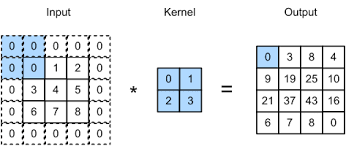

There are many different combinations of sections which could be taken, with the combination determined by the **stride**. The stride is the number of pixels the kernel moves by between each section taken.

For example for a stride of one the next section taken would be $\begin{bmatrix} 0 &0\\ 0 & 1 \end{bmatrix}$, but for a stride of two the next section taken would be $\begin{bmatrix} 0 & 0\\ 1 & 2 \end{bmatrix}.$

#### Exercise 1.2.1 
What would the next section be if the stride was three?

Additional to kernel size and stride there is a third hyperparameter, **padding**. This hyperparameter is important where the stride selected could lead to a kernel extending beyond the image. Padding conserves data at the edges of activation maps. One of the most common methods of padding is known as **zero-padding** and involves adding a suitably sized border of zeros around the image so that the outer layer of the image can be included within the convolution.

### 1.3 Pooling Layers
Pooling layers carry out dimensionality reduction helping to increase the efficiency of the network. This is especially important in the image classification context where there may be several layers representing colour, or a large number of pixels for high-resolution files.
The main example of pooling is Max Pooling, which takes the highest value from a kernel. For a 2x2 sized kernel with a stride of 2, this removes 75% of the data, greatly improving efficiency.

### 1.4 Training using Backpropagation
For traditional hidden layers backpropagation works the same as it does in an FNN, but the process is complicated by pooling and convolutional layers. For convolutional layers, the gradients are used to update filter weights and bias values, calculating how much each filter contributed to the prediction error to learn which features are the most useful (i.e. reduce the prediction error most significantly over time). Pooling layers do not have learnable weights so are not directly updated. For max pooling the error is passed only to the input that produced the maximum value with all other inputs set to zero gradient. For more technical detail on this process check out the [Medium](https://pavisj.medium.com/convolutions-and-backpropagations-46026a8f5d2c) article mentioned in the intro.



# 2 MNIST Digit Example
Whilst we try to keep all of our examples and exercises relevant to the wind industry, this week is not quite as straightforward - finding image based datasets in this context is tricky and there are fewer open-source wind datasets available. For this week we are instead working with one of the most classical introductory datasets to image processing and classification: the [MNIST database of handwitten digits](https://www.kaggle.com/datasets/hojjatk/mnist-dataset) which has 70,000 labelled examples of handwritten digits from 0-9. This week's example will attempt to build a CNN which can identify the numerical value 0-9 shown in an image of a handwritten digit.

Whilst this problem is not direct to the wind industry the skills and process will extend naturally to lots of applications such as:
- Classifying erosion and damage from drone imagery
- Classifying root-cause or damage type from maintenance report imagery
- Identifying wake severity from LIDAR graphs
- Land classification from satellite imagery

We will be using the tensorflow keras module to access the data and build our CNN, as well as a lot of our other regular packages. For those of you who have not used or installed tensorflow before you will need to uncomment the cell below before running the remainder of the code.

In [1]:
#pip install tensorflow.keras

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras import layers, models
import tensorflow as tf
import seaborn as sns
from sklearn.metrics import confusion_matrix

## 2.1 Data Setup

In [3]:
# Get our dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

This dataset is made up of 70,000 2 dimensional (28x28 pixel) images of black and white handwritten images. There are 60,000 training examples, and 10,000 test examples. Each pixel (number in the 28x28 matrix for each example) has a value between 0 and 255 indicating the saturation of that pixel, with 0 being completely white, and 255 being completely black. As such the dimensions of inputs (X_train, X_test) are (n_examples, n_rows, n_columns). The output labels (y_train, y_test) are one dimensional, simply a numerical value between 0 and 9 for each examples so have dimensions (n_examples).

In [4]:
print('Training set dimensions')
print(X_train.shape, y_train.shape)
print('Test set dimensions')
print(X_test.shape, y_test.shape)

Training set dimensions
(60000, 28, 28) (60000,)
Test set dimensions
(10000, 28, 28) (10000,)


Let's use matplotlib to see some examples of the images provided in our test dataset.

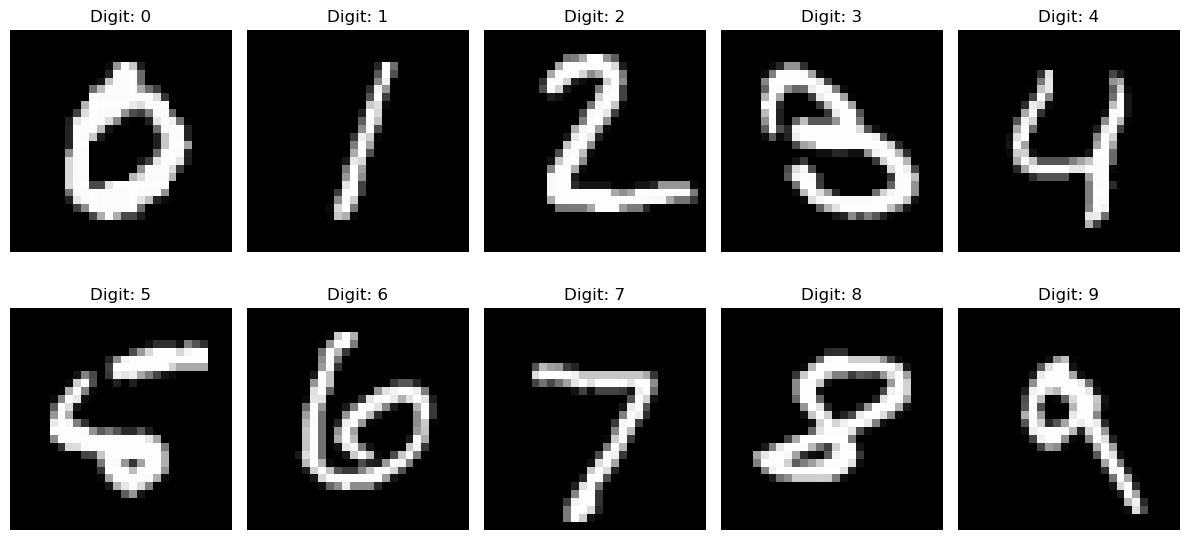

In [5]:
plt.figure(figsize=(12, 6))

# Plot one example of each digit 0-9
for digit in range(10):
    # Find first index of the digit
    idx = np.where(y_test == digit)[0][0]

    plt.subplot(2, 5, digit + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap="gray")
    plt.title(f"Digit: {digit}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Since the matrix values are between 0 and 255 we may normalise them to the [0,1] domain by dividing by 255.

In [6]:
# Normalize pixels to [0, 1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Add channel dimension: (28, 28) -> (28, 28, 1)
X_train = X_train[..., tf.newaxis]
X_test = X_test[..., tf.newaxis]

## 2.2 Model Building
Now that the data is prepared we can create our CNN model using the tensorflow Keras models module. The architecture we will create is outlined below: 
1. **Input Layer** – 28×28 image matrix normalised to [0-1] range
2. **Convolution + ReLU** – extracts simple features like edges and curves
3. **Max Pooling** – reduces image size and computation
4. **Second Convolution + ReLU** – learns more complex patterns
5. **Second Max Pooling** – further reduces image size and computation
6. **Third Convolution + ReLU** – captures higher-level digit features
7. **Flatten Layer** – converts feature maps into a 1D vector
8. **Dense Layer** – learns combinations of features
9. **Output Layer (Softmax)** – predicts probabilities for digits 0–9

In [7]:
# Build CNN
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

C:\Users\raby\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# Compile
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [9]:
# Train
model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9410 - loss: 0.1969 - val_accuracy: 0.9822 - val_loss: 0.0564
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9828 - loss: 0.0552 - val_accuracy: 0.9862 - val_loss: 0.0481
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9875 - loss: 0.0396 - val_accuracy: 0.9852 - val_loss: 0.0475
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9909 - loss: 0.0281 - val_accuracy: 0.9900 - val_loss: 0.0372
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9921 - loss: 0.0242 - val_accuracy: 0.9905 - val_loss: 0.0335


## 2.3 Model Evaluation

We can first use the model inbuilt evaluation method to calculate the loss and accuracy on the test set.

In [10]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")

313/313 - 1s - 3ms/step - accuracy: 0.9900 - loss: 0.0298
Test accuracy: 0.9900


Following that we can predict the specific values given x_test to look at more in-depth visualisations and measures. Since the predictions are output in the form of probability for each digit, to compare these predictions we need to first convert them into the highest probability digit by using the argmax() function.

In [11]:
y_pred = model.predict(X_test)
y_pred_digits = [np.argmax(y) for y in y_pred]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


We can then use this to view a plot of the confusion matrix to see which digits were most reliably predicted, and which were commonly mixed up.

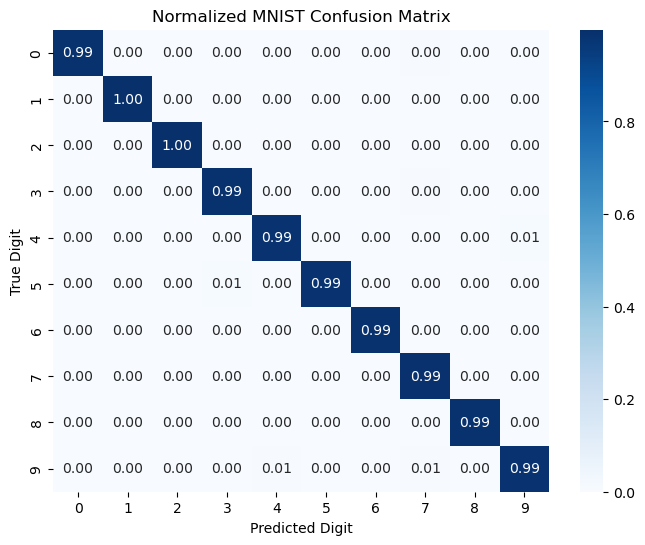

In [12]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_digits)

# Normalize by row (true labels)
cm_normalised = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

# Plot normalized heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_normalised,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Predicted Digit")
plt.ylabel("True Digit")
plt.title("Normalized MNIST Confusion Matrix")
plt.show()

### Exercise 2.3.1
Analyse the confusion matrix above - which digits were best captured by the model, and which ones failed? Can you think of some reasons why?

### Exercise 2.3.2
How could we improve the performance for the digits with lower accuracy?

### Exercise 2.3.3 
Go back and tune the architecture of the model and the training methods (epochs, batch_size). Can you improve the model performance?